# DC Motor data processing

In [224]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns

# Free Running Test
## Rotor speed and position
First we need to load in the measurements.

In [225]:
# Load data from CSV file
csv_file = 'motor2.csv'

# Create dataframe containing raw data
raw_df = pd.read_csv(csv_file) 

Then let's plot the data.

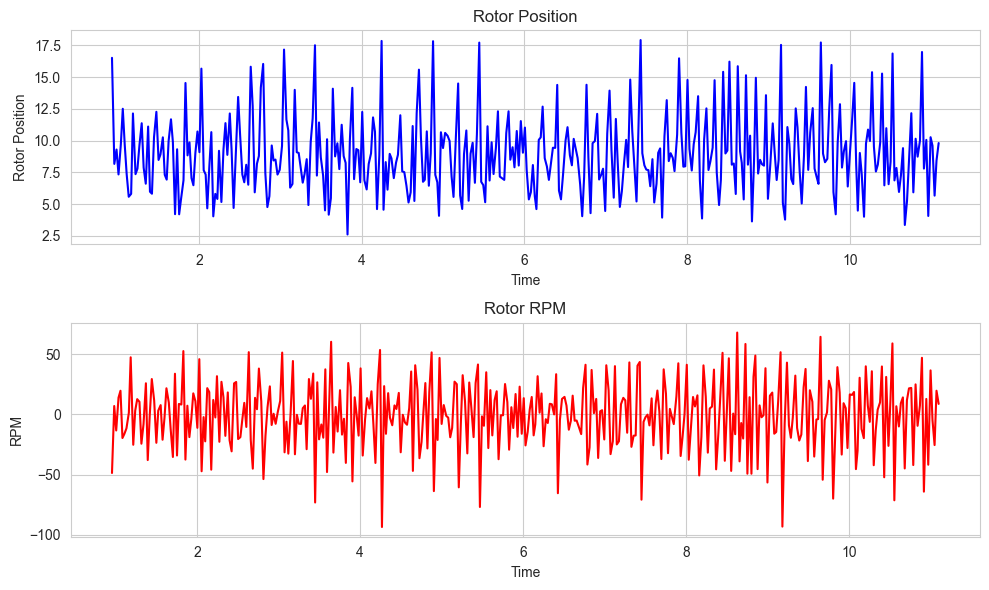

In [226]:
# Select example sample from data set
sample = 3
data_type = 2 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
rotor_data = pd.concat([raw_df.iloc[:, (5*sample + data_type)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
rotor_data.columns = ['rotor_position', 'Time']

# Calculate motor RPM from raw data
rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

# Plotting
## Create Figure
plt.figure(figsize=(10, 6))

## Rotor position plot
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['rotor_position'], color='blue')
plt.title("Rotor Position")
plt.xlabel('Time')
plt.ylabel('Rotor Position')

## Motor RPM plot
plt.subplot(2, 1, 2)
plt.plot(rotor_data['Time'][1:], rotor_data['RPM'][1:], color='red')  # Omit first row due to NaN in RPM calculation
plt.title("Rotor RPM")
plt.xlabel('Time')
plt.ylabel('RPM')

## Show plot
plt.tight_layout()
plt.show()

From the plot above, we see we counter two issues with the data:
- The rotor position goes from 0-359 degrees, resetting every 360 degrees.
- Every time the rotor position resets, the estimated velocity goes to the moon.
- The motor spins counter clock wise (CCW).

In order to improve the angular velocity estimate, we can do two things:
- Invert the rotor position data, from 359-0 to 0-359 degrees.
- Remove all negative values from the angular velocity estimate, since we know the motor spins in one direction at a constant speed.

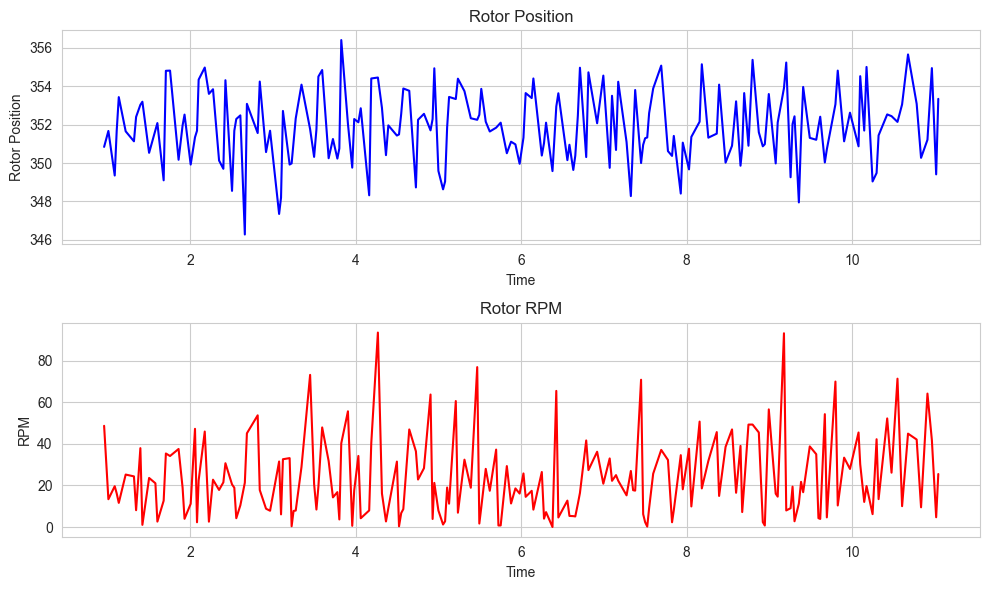

In [227]:
# Invert data
rotor_data['rotor_position'] = 359 - rotor_data['rotor_position'] 

# Calculate motor RPM from raw data
rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

# Remove negative values
rotor_data = rotor_data[rotor_data['RPM'] >= 0]



# Plotting
## Create Figure
plt.figure(figsize=(10, 6))

## Rotor position plot
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['rotor_position'], color='blue')
plt.title("Rotor Position")
plt.xlabel('Time')
plt.ylabel('Rotor Position')

## Motor RPM plot
plt.subplot(2, 1, 2)
plt.plot(rotor_data['Time'], rotor_data['RPM'], color='red') 
plt.title("Rotor RPM")
plt.xlabel('Time')
plt.ylabel('RPM')

## Show plot
plt.tight_layout()
plt.show()

Now the data is looking a lot more reasonable. But we can still we that the speed data is containing some artifacts. We can filter this out with outlier detection, and interpolate the missing values. 

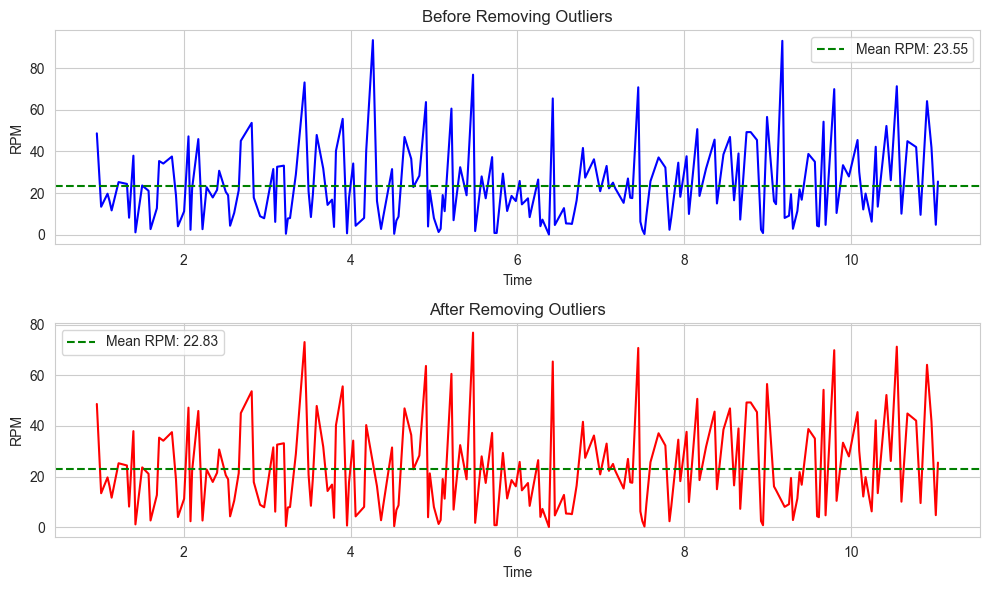

The mean RPM before outlier removal is: 23.5467 RPM
The mean RPM after outlier removal is: 22.8313 RPM
This amounts to a difference of: 0.7154 RPM


In [228]:
# Calculate z-scores for each value in the 'RPM' column
z_scores = stats.zscore(rotor_data['RPM'])

# Define a threshold for identifying outliers (e.g., 3 standard deviations from the mean)
threshold = 3

# Find the indices of outliers
outlier_indices = np.abs(z_scores) > threshold

# Remove outliers from the DataFrame
cleaned_rotor_data = rotor_data[~outlier_indices]


# Calculate mean RPM before removing outliers
mean_rpm_before = rotor_data['RPM'].mean()

# Calculate mean RPM after removing outliers
mean_rpm_after = cleaned_rotor_data['RPM'].mean()

# Plot 'RPM' column before removing outliers
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['RPM'], color='blue')
plt.axhline(y=mean_rpm_before, color='green', linestyle='--', label=f'Mean RPM: {mean_rpm_before:.2f}')
plt.title('Before Removing Outliers')
plt.xlabel('Time')
plt.ylabel('RPM')
plt.legend()

# Plot 'RPM' column after removing outliers
plt.subplot(2, 1, 2)
plt.plot(cleaned_rotor_data['Time'], cleaned_rotor_data['RPM'], color='red')
plt.axhline(y=mean_rpm_after, color='green', linestyle='--', label=f'Mean RPM: {mean_rpm_after:.2f}')
plt.title('After Removing Outliers')
plt.xlabel('Time')
plt.ylabel('RPM')
plt.legend()

plt.tight_layout()
plt.show()

# Lastly, update RPM in rotor_data
rotor_data['RPM'] = cleaned_rotor_data['RPM']

# Print mean RPM before and after outlier removal
print(f"The mean RPM before outlier removal is: {mean_rpm_before:.4f} RPM")
print(f"The mean RPM after outlier removal is: {mean_rpm_after:.4f} RPM")
print(f"This amounts to a difference of: {abs(mean_rpm_before - mean_rpm_after):.4f} RPM")



With this data filtering, we will assume that we have a decent data set, and can apply this to the entirety of the data.

In [229]:
RPM_df = pd.DataFrame()

# Assuming df is your dataframe
num_columns = len(raw_df.columns)

# Iterating through every fifth column
for sample in range(0, num_columns, 5):
    # Create new dataframe for rotor data, containing rotor position and time
    rotor_data = pd.concat([raw_df.iloc[:, (sample)], raw_df.iloc[:, (sample + 4)]], axis=1)
    rotor_data.columns = ['rotor_position', 'Time']

    ## Invert data
    rotor_data['rotor_position'] = 359 - rotor_data['rotor_position'] 

    # Calculate motor RPM from raw data
    rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

    # Remove negative values
    rotor_data = rotor_data[rotor_data['RPM'] >= 0]

    # Calculate z-scores for each value in the 'RPM' column
    z_scores = stats.zscore(rotor_data['RPM'])

    # Define a threshold for identifying outliers (e.g., 3 standard deviations from the mean)
    threshold = 3

    # Find the indices of outliers
    outlier_indices = np.abs(z_scores) > threshold

    # Remove outliers from the DataFrame
    cleaned_rotor_data = rotor_data[~outlier_indices]

    # Add to RPM dataframe
    RPM_df[f'{(sample/5) * 0.5}V'] = cleaned_rotor_data['RPM']  


# Final data clean up
# Replace "inf" values with NaN
RPM_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace NaN values in each column with interpolation
RPM_df = RPM_df.interpolate()

# Remove first rows with NaN values.
nan_index = RPM_df.index[RPM_df.isnull().any(axis=1)][0]
RPM_df = RPM_df.iloc[nan_index + 2:]

# Remove non-zero values from first column, we know the speed of the motor was zero.
RPM_df.iloc[:, 0] = 0

# Reset index to start from zero
RPM_df = RPM_df.reset_index(drop=True)

# Display Table
rounded_df = RPM_df.round(1)
rounded_df

c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,0.0V,0.5V,1.0V,1.5V,2.0V,2.5V,3.0V,3.5V,4.0V,4.5V,...,12.5V,13.0V,13.5V,14.0V,14.5V,15.0V,15.5V,16.0V,16.5V,17.0V
0,0.0,0.0,0.0,49.5,81.7,98.8,118.2,193.8,203.9,286.2,...,893.9,946.9,931.2,786.4,1044.5,1065.8,916.5,1258.9,975.2,1115.5
1,0.0,0.0,0.0,48.5,85.0,125.3,148.8,154.0,203.4,252.6,...,958.9,931.9,835.8,865.3,950.2,1037.1,1112.6,947.4,1056.4,1199.4
2,0.0,0.0,0.0,45.4,71.2,105.4,137.4,172.9,268.4,231.2,...,652.9,688.8,782.5,857.0,855.9,1024.1,1087.1,942.9,1137.6,1199.8
3,0.0,0.0,0.0,38.2,70.2,107.9,136.2,194.4,230.4,253.1,...,710.0,792.3,768.1,848.7,846.2,1011.0,1061.7,938.4,983.4,1200.1
4,0.0,0.0,0.0,50.5,88.9,112.7,120.6,157.8,202.8,253.1,...,877.9,920.0,1056.4,911.1,836.5,997.9,1036.2,933.9,982.4,1200.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,0.0,0.0,0.0,47.9,98.1,97.9,152.9,150.3,204.6,244.6,...,818.3,698.9,745.3,1009.6,864.3,963.8,1121.6,1126.4,971.3,1201.3
344,0.0,0.0,0.0,37.2,71.4,103.9,178.5,158.1,236.5,231.7,...,874.1,845.6,790.4,1060.4,854.3,886.2,1106.9,1132.9,971.9,1192.7
345,0.0,0.0,0.0,47.8,73.2,133.0,162.2,165.9,195.7,218.8,...,687.1,817.0,835.6,1097.9,1103.0,906.5,1092.1,1121.6,972.4,1133.0
346,0.0,0.0,0.0,49.8,76.1,129.0,145.8,168.3,216.8,246.0,...,765.6,788.5,830.6,1135.4,933.5,1064.8,1016.9,1110.4,1016.2,1073.3


Regression line:  y(x) = 0.905 + 0.0145x.
Regression line:  V(RPM) = 0.905V + 0.0145*RPM.


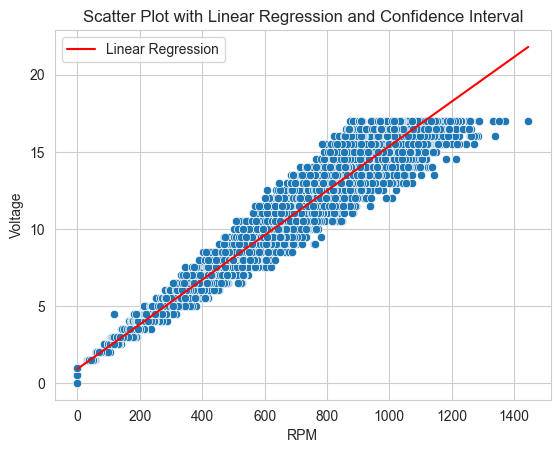

In [230]:
# Initialize empty numpy arrays for x and y
x = np.array([])
y = np.array([])

n = 0
# Loop through each column in the DataFrame
for column in RPM_df.columns:
    # Add values from the column to y array
    x = np.append(x, RPM_df[column].values)
    
    # Add an array of 2s to x array (assuming the same length as y)
    y = np.append(y, np.full_like(RPM_df[column].values, n*0.5))
    n += 1


# Perform linear regression
slope, intercept, _, _, stderr = stats.linregress(x, y)
print("Regression line:  y(x) = {:.3f} + {:.4f}x.".format(intercept, abs(slope)))
print("Regression line:  V(RPM) = {:.3f}V + {:.4f}*RPM.".format(intercept, abs(slope)))
# Calculate confidence interval
conf_interval = 1.96 * stderr  # 95% confidence interval

# Create scatter plot of x and y values with seaborn
sns.scatterplot(x=x, y=y)

# Plot the regression line with confidence interval using seaborn
sns.lineplot(x=x, y=slope * x + intercept, color='red', label='Linear Regression', err_style='band')

# Add labels and title
plt.xlabel('RPM')
plt.ylabel('Voltage')
plt.title('Scatter Plot with Linear Regression and Confidence Interval')

# Show the plot
plt.legend()  # Show legend
plt.show()

While we now have a linear equation for motor speed vs voltage, we still lack part of the equation:
$$V = R \cdot I + k_e \cdot \omega$$

In our regression line, $R \cdot I$ is constant, while it actuality, it varies by current. We can fix this by including the current measurement data, and offsetting the voltages by the voltage drop caused by the internal resistance in the motor. 

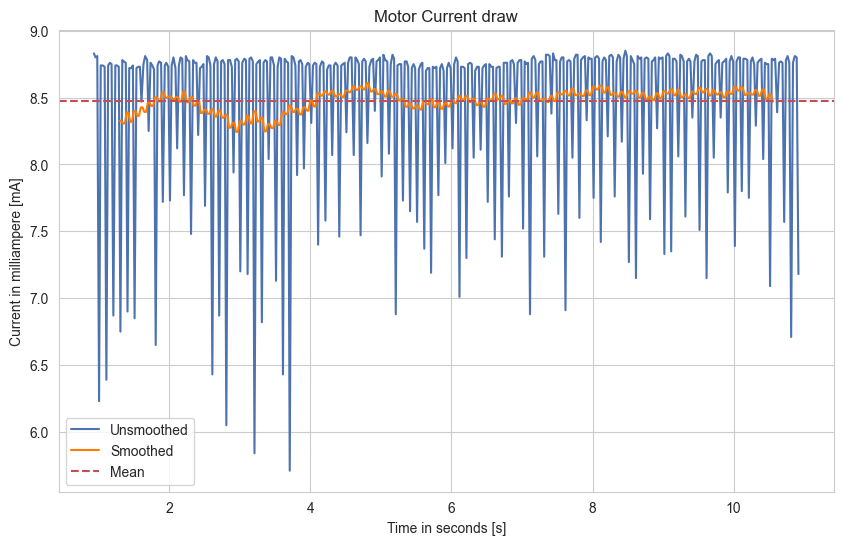

Mean Current: 0.00846735


In [255]:
# Select example sample from data set
sample = 2
data_type = 2 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
current_data = pd.concat([raw_df.iloc[:, (5*sample + data_type)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
current_data.columns = ['Current', 'Time']

# Apply the moving average using rolling method
window_size = 30
smoothed_df = current_data.rolling(window=window_size).mean()

# Drop rows with NaN values introduced by rolling method
smoothed_df.dropna(inplace=True)


# Plotting
# Set the style
sns.set_style("whitegrid")

# Accessing similar colors in seaborn's color palette
royal_blue = sns.color_palette('deep')[0]  # Similar to royal blue
bright_green = sns.color_palette('bright')[1]  # Higher contrast green color
coral_pink = sns.color_palette('deep')[3]  # Similar to coral pink

# Create Figure
plt.figure(figsize=(10, 6))

# Plot unsmoothed data with royal blue color
plt.plot(current_data['Time'], current_data['Current'], color=royal_blue, label='Unsmoothed')

# Plot smoothed data with brighter green color
plt.plot(smoothed_df['Time'], smoothed_df['Current'], color=bright_green, label='Smoothed')

# Plot horizontal line for the mean value with coral pink color
plt.axhline(y=smoothed_df['Current'].mean(), color=coral_pink, linestyle='--', label='Mean')

# Add labels and title
plt.xlabel('Time in seconds [s]')
plt.ylabel('Current in milliampere [mA]')
plt.title('Motor Current draw')

# Add legend
plt.legend()

# Show the plot
plt.show()

# Print the mean voltage
print("Mean Current:", (current_data['Current'].mean()/1000))

In [279]:
# Select example sample from data set
sample = 2
data_type = 2 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
voltage_data = pd.concat([raw_df.iloc[:, (5*sample + 1)], raw_df.iloc[:, (5*sample + 2)], raw_df.iloc[:, (5*sample + 3)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
voltage_data.columns = ['V_bus', 'V_shunt', "Current", "Time"]

# Change V_shunt from mV to V and Current from mA to A
voltage_data['V_shunt'] = voltage_data['V_shunt'] / 1000
voltage_data["Current"] = voltage_data["Current"] / 1000

# Calculate armature resistance.
voltage_data["Armature Resistance"] = (   0.5 - voltage_data['V_shunt'] ) / voltage_data['Current']

print((voltage_data['Armature Resistance'].mean()))
print((voltage_data['Armature Resistance'].mean()) * voltage_data['Current'].mean())


5.963031023967565
0.49990474286329684


In [244]:
resis = []
# Iterating through every fifth column
for sample in range(0, 15, 5):
    # Create new dataframe for rotor data, containing rotor position and time
    voltage_data = pd.concat([raw_df.iloc[:, (5*sample + 1)], raw_df.iloc[:, (5*sample + 2)], raw_df.iloc[:, (5*sample + 3)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
    voltage_data.columns = ['V_bus', 'V_shunt', "Current", "Time"]

    # Change V_shunt from mV to V
    voltage_data['V_shunt'] = voltage_data['V_shunt'] / 1000

    # Calculate armature resistance.
    res = ( voltage_data['V_bus']  - voltage_data['V_shunt'] ) / voltage_data['Current'] 
    resis.append(res.mean())

print(np.mean(resis))



nan


c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
